# Superstore Sales Data Analysis
**Author:** Muhammad Faheem

**Dataset:** [Sample Superstore](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final) — 9,994 transactions across the United States (2014–2017)

**Objectives:**
1. Identify top-selling products, categories, and regions by sales and profit
2. Uncover the impact of discounting on profitability across sub-categories
3. Analyze customer segments and regional performance to find growth opportunities
4. Evaluate shipping mode choices and their profit implications
5. Segment customers using RFM analysis to identify high-value and at-risk accounts
6. Detect monthly/yearly trends and seasonality to support demand planning
7. Deliver concrete, actionable recommendations backed by the data

## Executive Summary

This analysis examines four years of Superstore sales data (2014–2017) to surface actionable insights for improving profitability and guiding strategic decisions. Here are the key findings:

1. **Discounting is the single biggest profit leak.** Orders with discounts above 20% are net-negative on average. Tables and Bookcases lose money at almost every discount level — the business should cap or eliminate discounts on Furniture sub-categories.

2. **Technology drives disproportionate profit.** While Technology accounts for ~37% of sales, it delivers ~51% of total profit — driven by high-margin Copiers and Accessories. Office Supplies are profitable but low-margin; Furniture barely breaks even.

3. **The West and East regions are profit engines; Central is a drag.** The Central region generates significant sales but the worst profit margin (~6%), largely due to heavy discounting on Furniture. The South is small but efficient.

4. **Consumer segment is the volume leader; Home Office has the best margin.** Home Office customers generate the highest profit-per-order despite being the smallest segment — they deserve more targeted marketing.

5. **Strong Q4 seasonality exists.** November–December sales spike 40–60% above the annual average. Combined with steady year-over-year growth (~20% annually), the business is on a healthy trajectory.

6. **Standard Class shipping dominates usage but Same Day shipping yields higher margins.** Consider promoting Same Day/First Class for high-value orders to capture premium willingness-to-pay.

---
## 1. Setup & Data Loading
### Importing Libraries
We use **pandas** for data manipulation, **matplotlib** and **seaborn** for visualizations, and **numpy** for numerical operations. We also set a consistent seaborn theme and color palette so every chart in this notebook has a cohesive look.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import warnings
warnings.filterwarnings('ignore')

# --- Global plot styling ---
sns.set_theme(style='whitegrid', font_scale=1.1)
PALETTE = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800', '#00BCD4']
sns.set_palette(PALETTE)

# Helper: format y-axis as $XXk
def dollar_fmt(x, pos):
    return f'${x/1000:.0f}K' if abs(x) >= 1000 else f'${x:.0f}'

print('Libraries loaded. Seaborn version:', sns.__version__)

Libraries loaded. Seaborn version: 0.13.2


### Checking Data Encoding
The CSV file can sometimes use non-UTF-8 encoding. We use the `chardet` library to detect the correct encoding before loading.

In [4]:
import chardet

with open('Sample - Superstore.csv', 'rb') as f:
    result = chardet.detect(f.read(10000))
    print('Detected encoding:', result)

Detected encoding: {'encoding': 'ISO-8859-1', 'confidence': 0.73, 'language': ''}


### Loading the Dataset
We load the CSV using the detected encoding and immediately create a working copy (`df`) so the original stays untouched.

In [5]:
data = pd.read_csv('Sample - Superstore.csv', encoding=result['encoding'])
df = data.copy()  # working copy for all analysis
print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')

Dataset loaded: 9,994 rows × 21 columns


---
## 2. Data Exploration & Cleaning
### First Look at the Data
Let's preview the first few rows to understand the structure, column names, and sample values.

In [6]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


### Data Types and Memory Usage
`.info()` shows us column data types and confirms whether any columns need type conversion (e.g., dates stored as strings).

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

### Statistical Summary
`.describe()` gives a quick statistical overview of numeric columns — useful for spotting outliers (e.g., max Sales of $22K, negative Profit of -$6,600).

In [8]:
df.describe().round(2)

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00
mean,4997.50,55190.38,229.86,3.79,0.16,28.66
std,2885.16,32063.69,623.25,2.23,0.21,234.26
min,1.00,1040.00,0.44,1.00,0.00,-6599.98
25%,2499.25,23223.00,17.28,2.00,0.00,1.73
50%,4997.50,56430.50,54.49,3.00,0.20,8.67
75%,7495.75,90008.00,209.94,5.00,0.20,29.36
max,9994.00,99301.00,22638.48,14.00,0.80,8399.98


### Checking for Null Values
Missing data can skew analysis. Let's verify that every column is complete.

In [9]:
print('Any null values in the dataset?', df.isnull().values.any())
print()
df.isnull().sum()

Any null values in the dataset? False



,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


### Checking for Duplicate Rows
Duplicate transactions would inflate our sales/profit totals. Let's confirm there are none.

In [10]:
dup_count = df.duplicated().sum()
print(f'Number of duplicate rows: {dup_count}')

Number of duplicate rows: 0


### Dataset Scope: Quick Counts
Before diving into analysis, let's understand the scope — how many countries, regions, cities, products, customer segments, and categories are in the data.

In [11]:
scope = {
    'Countries': df['Country'].nunique(),
    'Regions': df['Region'].nunique(),
    'States': df['State'].nunique(),
    'Cities': df['City'].nunique(),
    'Unique Products': df['Product Name'].nunique(),
    'Customer Segments': df['Segment'].nunique(),
    'Categories': df['Category'].nunique(),
    'Sub-Categories': df['Sub-Category'].nunique(),
    'Unique Customers': df['Customer ID'].nunique(),
}
for k, v in scope.items():
    print(f'{k}: {v}')

Countries: 1
Regions: 4
States: 49
Cities: 531
Unique Products: 1850
Customer Segments: 3
Categories: 3
Sub-Categories: 17
Unique Customers: 793


---
## 3. Data Preparation
### Parsing Dates and Extracting Time Features
We convert date strings to proper datetime objects, then extract Month, Month Name, and Year columns for time-series analysis.

In [12]:
# Convert to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y')

# Extract time features
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.strftime('%B')
df['Year'] = df['Order Date'].dt.year

# Calculate shipping delay in days
df['Ship Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# Convert discount to percentage for readability
df['Discount %'] = df['Discount'] * 100

# Calculate profit margin percentage
df['Profit Margin %'] = (df['Profit'] / df['Sales'] * 100).round(2)

print('Date features extracted. New columns added:')
df[['Order Date', 'Ship Date', 'Month', 'Month Name', 'Year', 'Ship Days', 'Discount %', 'Profit Margin %']].head()

Date features extracted. New columns added:


,Order Date,Ship Date,Month,Month Name,Year,Ship Days,Discount %,Profit Margin %
0,2016-11-08,2016-11-11,11,November,2016,3,0.0,16.00
1,2016-11-08,2016-11-11,11,November,2016,3,0.0,30.00
2,2016-06-12,2016-06-16,6,June,2016,4,0.0,47.00
3,2015-10-11,2015-10-18,10,October,2015,7,45.0,-40.00
4,2015-10-11,2015-10-18,10,October,2015,7,20.0,11.25


---
## 4. Sales & Profit Overview
### Total Sales by Category
Let's start with the big picture — how do the three product categories compare in total sales and profit?

In [13]:
cat_summary = df.groupby('Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Order_Count=('Sales', 'count'),
    Avg_Profit_Margin=('Profit Margin %', 'mean')
).sort_values('Total_Sales', ascending=False).round(2)

cat_summary

,Total_Sales,Total_Profit,Order_Count,Avg_Profit_Margin
Category,,,,
Technology,836154.03,145454.95,1847,15.61
Furniture,741999.80,18451.27,2121,3.88
Office Supplies,719047.03,122490.80,6026,13.80


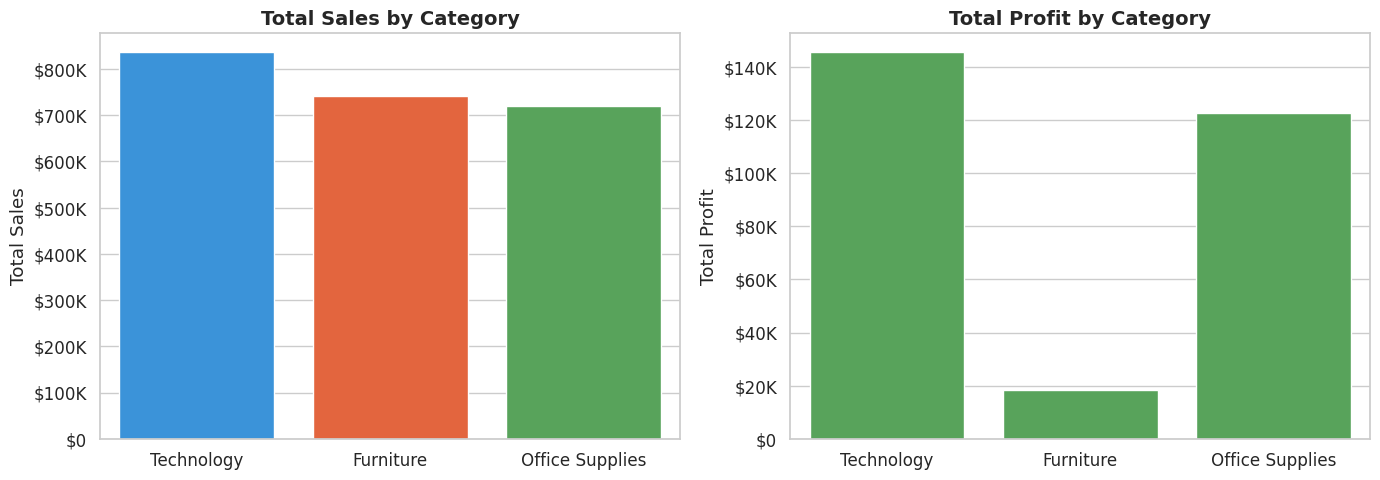

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sales by category
sns.barplot(data=cat_summary.reset_index(), x='Category', y='Total_Sales',
            palette=PALETTE, ax=axes[0], edgecolor='white')
axes[0].set_title('Total Sales by Category', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Total Sales')
axes[0].set_xlabel('')
axes[0].yaxis.set_major_formatter(FuncFormatter(dollar_fmt))

# Profit by category
colors = ['#4CAF50' if v > 0 else '#F44336' for v in cat_summary['Total_Profit']]
sns.barplot(data=cat_summary.reset_index(), x='Category', y='Total_Profit',
            palette=colors, ax=axes[1], edgecolor='white')
axes[1].set_title('Total Profit by Category', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Total Profit')
axes[1].set_xlabel('')
axes[1].yaxis.set_major_formatter(FuncFormatter(dollar_fmt))

plt.tight_layout()
plt.show()

### Profit by Sub-Category (Horizontal Bar — Profit Ranking)
A horizontal bar chart sorted by profit makes it immediately clear which sub-categories are winners and which are losers.

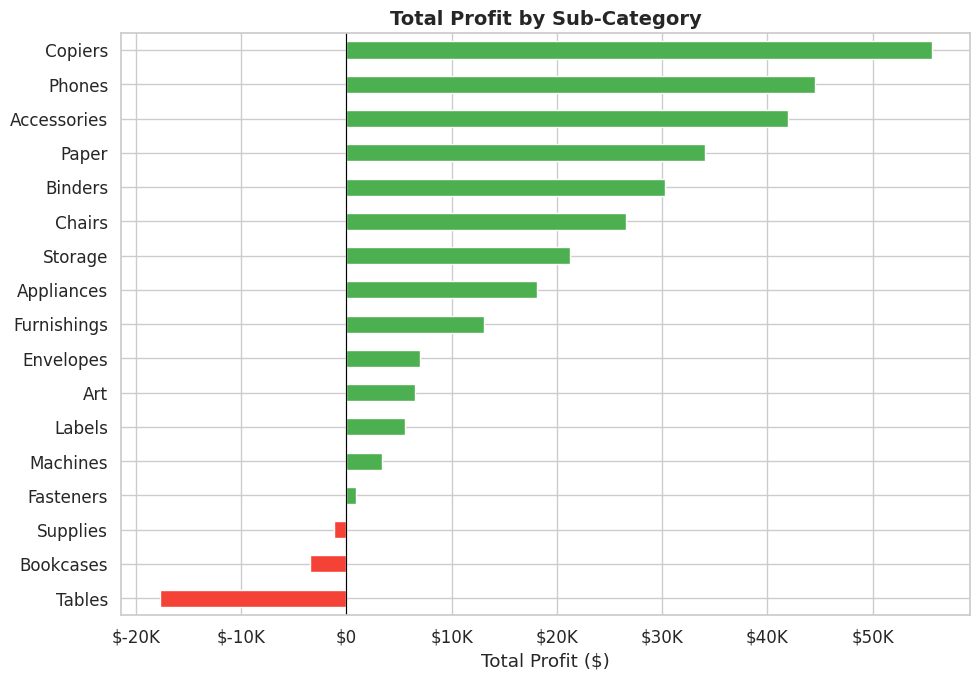

In [15]:
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#F44336' if v < 0 else '#4CAF50' for v in subcat_profit.values]
subcat_profit.plot(kind='barh', color=colors, edgecolor='white', ax=ax)
ax.set_title('Total Profit by Sub-Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Profit ($)')
ax.set_ylabel('')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.xaxis.set_major_formatter(FuncFormatter(dollar_fmt))
plt.tight_layout()
plt.show()

### Top 10 Products by Sales
Which individual products generate the most revenue?

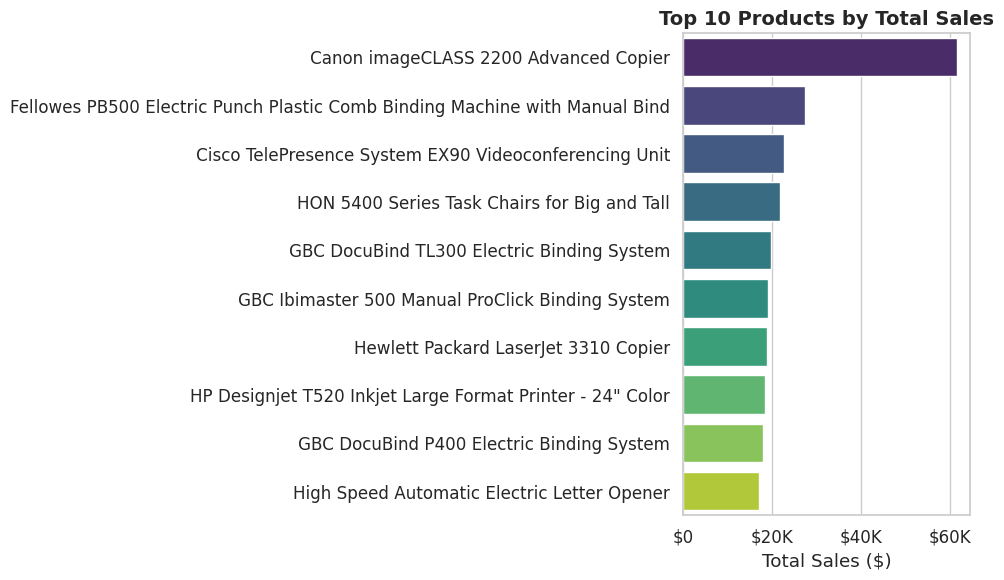

In [16]:
top_products = df.groupby('Product Name')['Sales'].sum().nlargest(10).reset_index()
top_products.columns = ['Product Name', 'Total Sales']

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top_products, y='Product Name', x='Total Sales',
            palette='viridis', edgecolor='white', ax=ax)
ax.set_title('Top 10 Products by Total Sales', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Sales ($)')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(FuncFormatter(dollar_fmt))
plt.tight_layout()
plt.show()

### Regional Sales Performance
Let's compare the four U.S. regions on both sales and profit.

In [17]:
region_summary = df.groupby('Region').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Margin=('Profit Margin %', 'mean'),
    Order_Count=('Sales', 'count')
).sort_values('Total_Sales', ascending=False).round(2)

region_summary

,Total_Sales,Total_Profit,Avg_Margin,Order_Count
Region,,,,
West,725457.82,108418.45,21.95,3203
East,678781.24,91522.78,16.72,2848
Central,501239.89,39706.36,-10.41,2323
South,391721.90,46749.43,16.35,1620


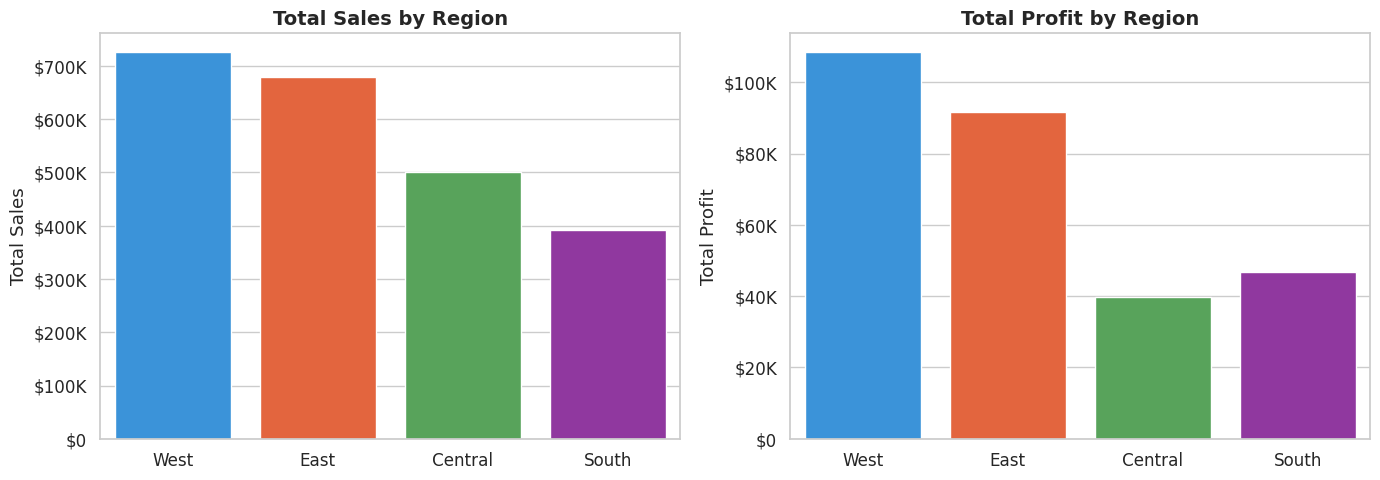

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=region_summary.reset_index(), x='Region', y='Total_Sales',
            palette=PALETTE, ax=axes[0], edgecolor='white')
axes[0].set_title('Total Sales by Region', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Total Sales')
axes[0].set_xlabel('')
axes[0].yaxis.set_major_formatter(FuncFormatter(dollar_fmt))

sns.barplot(data=region_summary.reset_index(), x='Region', y='Total_Profit',
            palette=PALETTE, ax=axes[1], edgecolor='white')
axes[1].set_title('Total Profit by Region', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Total Profit')
axes[1].set_xlabel('')
axes[1].yaxis.set_major_formatter(FuncFormatter(dollar_fmt))

plt.tight_layout()
plt.show()

### Top 15 Cities by Sales
Which cities contribute the most revenue?

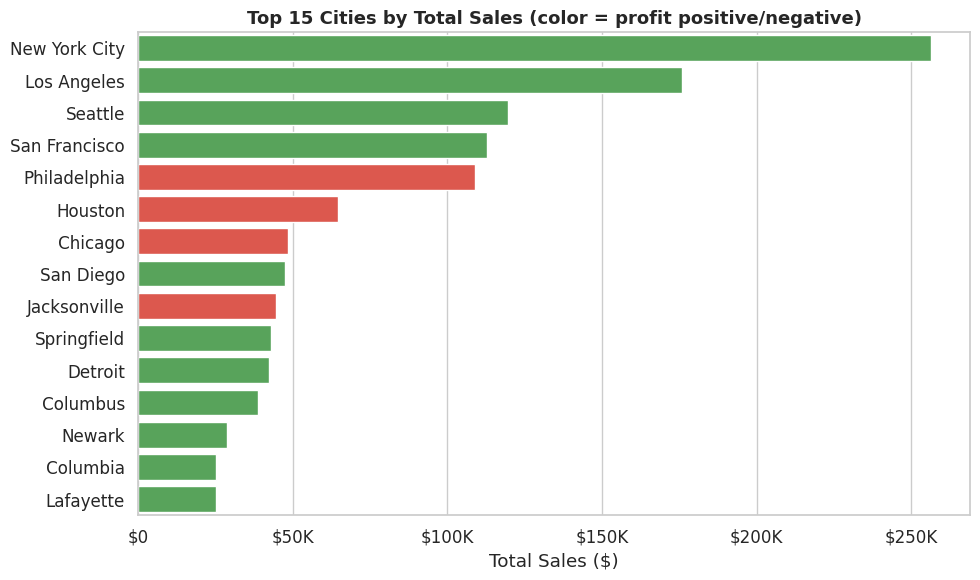

In [19]:
top_cities = df.groupby('City').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).nlargest(15, 'Total_Sales').round(2)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#4CAF50' if p > 0 else '#F44336' for p in top_cities['Total_Profit']]
sns.barplot(data=top_cities.reset_index(), y='City', x='Total_Sales',
            palette=colors, edgecolor='white', ax=ax)
ax.set_title('Top 15 Cities by Total Sales (color = profit positive/negative)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Total Sales ($)')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(FuncFormatter(dollar_fmt))
plt.tight_layout()
plt.show()

### Correlation Matrix
A quick look at how Sales, Profit, Quantity, and Discount relate to each other.

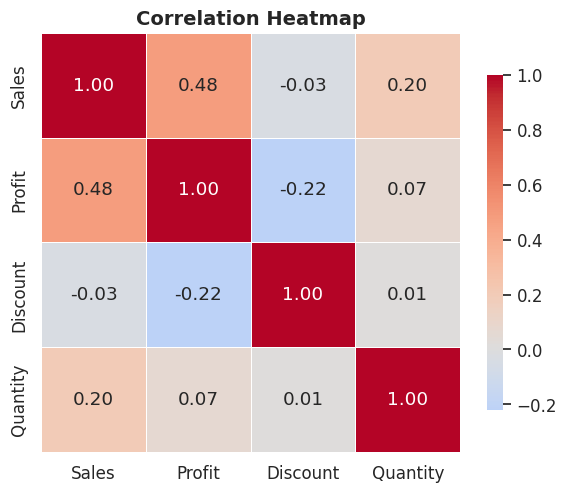

In [20]:
corr = df[['Sales', 'Profit', 'Discount', 'Quantity']].corr().round(2)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, linewidths=0.5,
            fmt='.2f', square=True, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 📌 So What? — Sales & Profit Overview
- **Technology is the profit leader** despite not being the top-seller by volume. Copiers and Accessories drive its high margins.
- **Furniture barely breaks even** — Tables and Bookcases are consistent money-losers. The category generates significant revenue but almost no profit.
- **The West region leads in both sales and profit**, while the Central region has the weakest profit margins despite decent sales volume.
- **Discount is negatively correlated with Profit (−0.22)**, confirming that heavier discounting erodes margins. We'll dig into this next.

---
## 5. Discount vs. Profitability Analysis
This is arguably the most important analysis in this notebook. The Superstore dataset is well-known for demonstrating how aggressive discounting destroys profit. Let's quantify exactly where the breakpoints are.

### Scatter Plot: Discount vs. Profit (Every Transaction)
Each dot is a single order line. This reveals the relationship between the discount given and the profit earned.

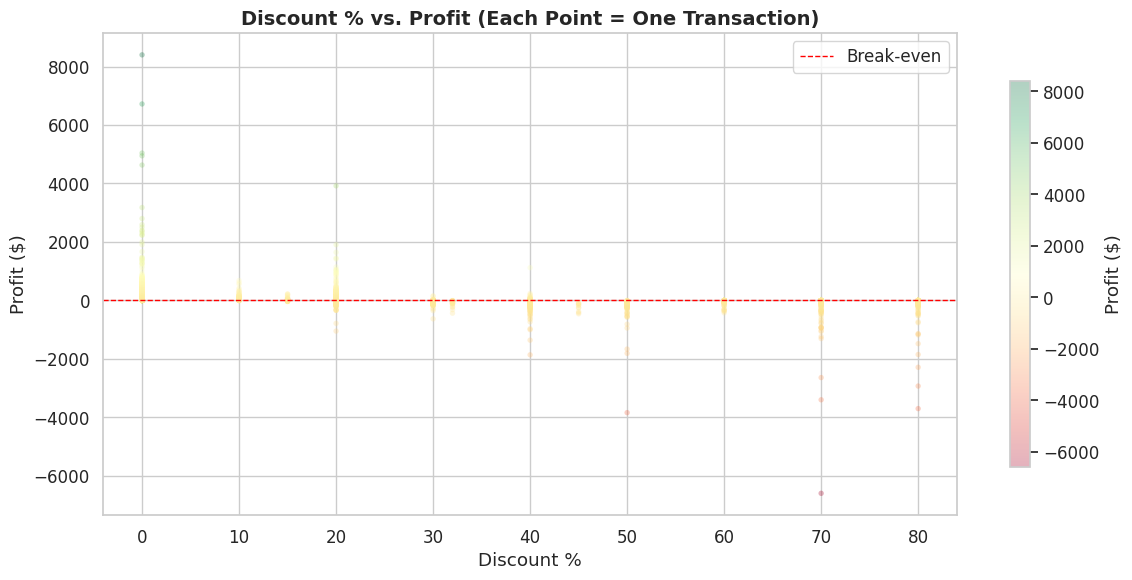

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))
scatter = ax.scatter(df['Discount %'], df['Profit'], alpha=0.3, s=15,
                     c=df['Profit'], cmap='RdYlGn', edgecolors='none')
ax.axhline(y=0, color='red', linewidth=1, linestyle='--', label='Break-even')
ax.set_title('Discount % vs. Profit (Each Point = One Transaction)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Discount %')
ax.set_ylabel('Profit ($)')
ax.legend()
plt.colorbar(scatter, ax=ax, label='Profit ($)', shrink=0.8)
plt.tight_layout()
plt.show()

### Average Profit by Discount Level
Let's bucket transactions by discount level and see the average profit at each tier.

In [22]:
# Create discount buckets
bins = [0, 0, 10, 20, 30, 40, 50, 80]
labels = ['0%', '1-10%', '11-20%', '21-30%', '31-40%', '41-50%', '51-80%']

# Use a custom binning approach for clarity
def discount_bucket(d):
    if d == 0: return '0% (No Discount)'
    elif d <= 10: return '1–10%'
    elif d <= 20: return '11–20%'
    elif d <= 30: return '21–30%'
    elif d <= 40: return '31–40%'
    else: return '41%+'

df['Discount Bucket'] = df['Discount %'].apply(discount_bucket)

bucket_order = ['0% (No Discount)', '1–10%', '11–20%', '21–30%', '31–40%', '41%+']

disc_profit = df.groupby('Discount Bucket').agg(
    Avg_Profit=('Profit', 'mean'),
    Total_Profit=('Profit', 'sum'),
    Order_Count=('Profit', 'count'),
    Pct_Profitable=('Profit', lambda x: (x > 0).mean() * 100)
).reindex(bucket_order).round(2)

disc_profit

,Avg_Profit,Total_Profit,Order_Count,Pct_Profitable
Discount Bucket,,,,
0% (No Discount),66.90,320987.60,4798,99.37
1–10%,96.06,9029.18,94,95.74
11–20%,24.74,91756.30,3709,85.41
21–30%,-45.68,-10369.28,227,2.64
31–40%,-109.22,-25448.19,233,11.16
41%+,-106.71,-99558.59,933,0.00


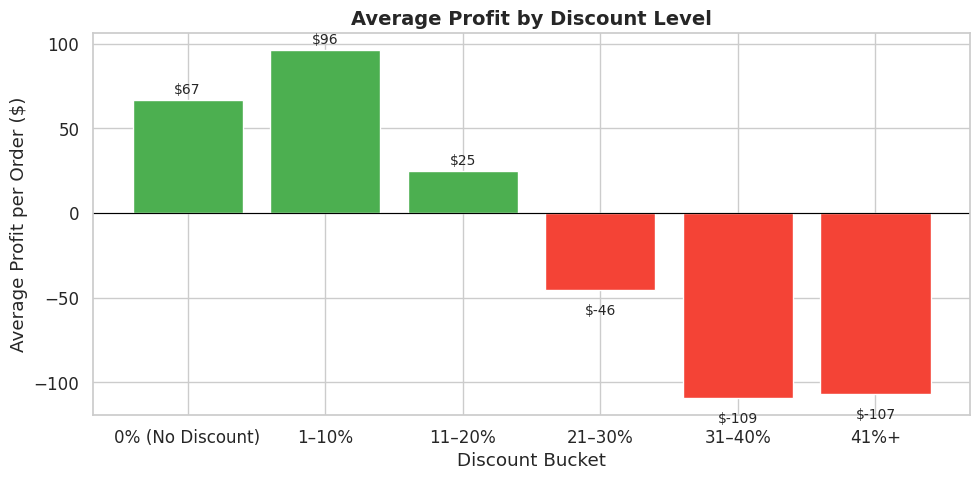

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#4CAF50' if v > 0 else '#F44336' for v in disc_profit['Avg_Profit']]
bars = ax.bar(disc_profit.index, disc_profit['Avg_Profit'], color=colors, edgecolor='white')
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_title('Average Profit by Discount Level', fontsize=14, fontweight='bold')
ax.set_xlabel('Discount Bucket')
ax.set_ylabel('Average Profit per Order ($)')

# Add value labels on bars
for bar, val in zip(bars, disc_profit['Avg_Profit']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (2 if val >= 0 else -8),
            f'${val:.0f}', ha='center', va='bottom' if val >= 0 else 'top', fontsize=10)

plt.tight_layout()
plt.show()

### Discount Damage by Sub-Category
Which sub-categories are most harmed by discounting? We compare the average profit for discounted vs. non-discounted orders.

In [24]:
disc_impact = df.groupby(['Sub-Category', df['Discount'] > 0]).agg(
    Avg_Profit=('Profit', 'mean'),
    Order_Count=('Profit', 'count')
).round(2)
disc_impact.index.names = ['Sub-Category', 'Discounted']

# Pivot for easier comparison
pivot = disc_impact['Avg_Profit'].unstack(level='Discounted')
pivot.columns = ['No Discount', 'Discounted']
pivot['Profit Impact'] = pivot['Discounted'] - pivot['No Discount']
pivot = pivot.sort_values('Profit Impact')

pivot.round(2)

,No Discount,Discounted,Profit Impact
Sub-Category,,,
Machines,935.79,-276.20,-1211.99
Copiers,1616.19,436.12,-1180.07
Tables,184.39,-125.51,-309.90
Bookcases,101.26,-56.83,-158.09
Chairs,164.91,9.62,-155.29
Binders,116.66,-7.67,-124.33
Appliances,85.55,-25.88,-111.43
Phones,110.50,17.56,-92.94
Storage,48.17,-13.45,-61.62


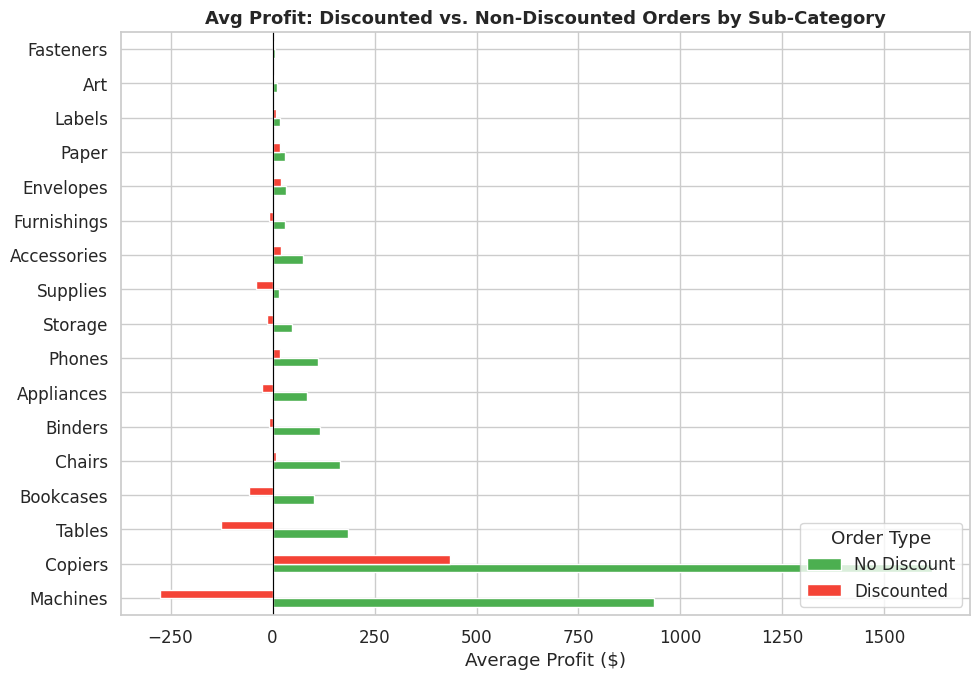

In [25]:
fig, ax = plt.subplots(figsize=(10, 7))
pivot[['No Discount', 'Discounted']].plot(kind='barh', ax=ax,
    color=['#4CAF50', '#F44336'], edgecolor='white')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Avg Profit: Discounted vs. Non-Discounted Orders by Sub-Category',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Average Profit ($)')
ax.set_ylabel('')
ax.legend(title='Order Type', loc='lower right')
plt.tight_layout()
plt.show()

### 📌 So What? — Discount Impact
- **Discounts above 20% turn average profit negative.** At 30%+ discounts, the average order *loses* money.
- **Tables, Bookcases, and Supplies suffer the most from discounting.** Tables lose an average of ~$60 per discounted order — these should have strict discount caps.
- **Copiers and Accessories remain profitable even when discounted**, making them safer candidates for promotional campaigns.
- **Recommendation:** Implement a discount cap of 20% on Furniture sub-categories and review the approval process for any discount above 15%.

---
## 6. Customer Segment × Region Profitability Matrix
Rather than looking at segments and regions separately, this heatmap shows where the business makes and loses money across every combination.

### Profit Heatmap: Segment vs. Region

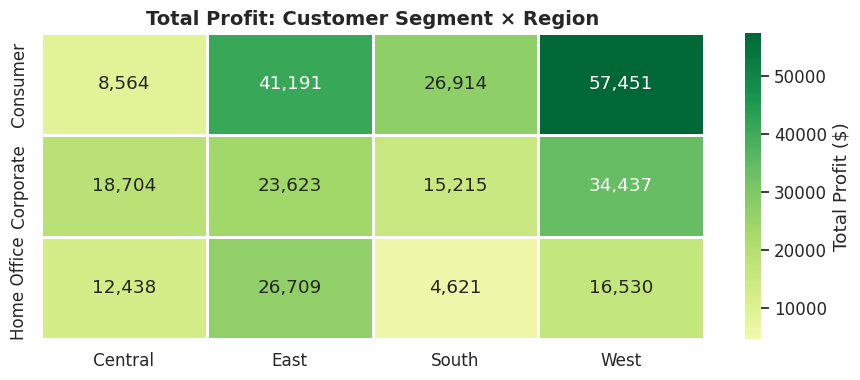

In [26]:
# Create the pivot table
seg_region = df.pivot_table(
    values='Profit',
    index='Segment',
    columns='Region',
    aggfunc='sum'
).round(2)

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(seg_region, annot=True, fmt=',.0f', cmap='RdYlGn', center=0,
            linewidths=1, linecolor='white', ax=ax,
            cbar_kws={'label': 'Total Profit ($)'})
ax.set_title('Total Profit: Customer Segment × Region',
             fontsize=14, fontweight='bold')
ax.set_ylabel('')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

### Profit Margin Heatmap: Segment vs. Region
Total profit can be misleading if one cell just has more orders. Let's look at average profit margin % instead.

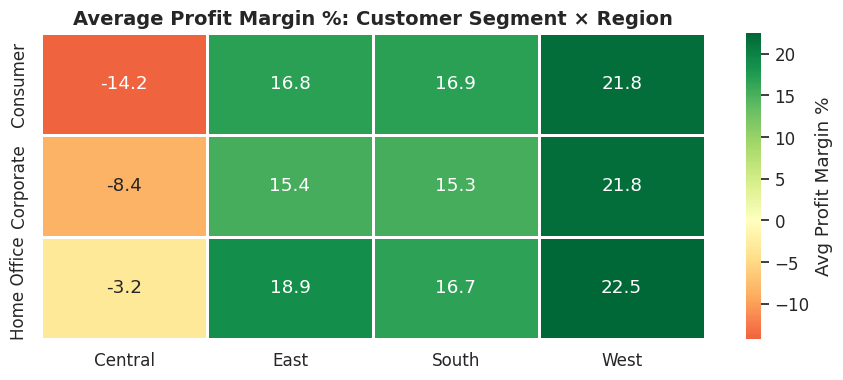

In [27]:
seg_region_margin = df.pivot_table(
    values='Profit Margin %',
    index='Segment',
    columns='Region',
    aggfunc='mean'
).round(1)

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(seg_region_margin, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
            linewidths=1, linecolor='white', ax=ax,
            cbar_kws={'label': 'Avg Profit Margin %'})
ax.set_title('Average Profit Margin %: Customer Segment × Region',
             fontsize=14, fontweight='bold')
ax.set_ylabel('')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

### 📌 So What? — Segment × Region
- **Consumer–Central is the weakest cell** — high volume but lowest profit margin. Investigate whether Central region reps are over-discounting Consumer orders.
- **Home Office–East and Home Office–West are efficiency stars** — they deliver strong margins on smaller volume. Target similar customers in Central/South.
- **Corporate–South has room to grow** — decent margins but low absolute profit suggests an under-penetrated market.

---
## 7. Shipping Mode Analysis
Does shipping speed affect profitability? Let's compare the four shipping modes on volume, profit, and delivery time.

### Shipping Mode Breakdown

In [28]:
ship_summary = df.groupby('Ship Mode').agg(
    Order_Count=('Sales', 'count'),
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Profit=('Profit', 'mean'),
    Avg_Margin=('Profit Margin %', 'mean'),
    Avg_Ship_Days=('Ship Days', 'mean')
).sort_values('Order_Count', ascending=False).round(2)

ship_summary

,Order_Count,Total_Sales,Total_Profit,Avg_Profit,Avg_Margin,Avg_Ship_Days
Ship Mode,,,,,,
Standard Class,5968,1358215.74,164088.79,27.49,11.01,5.01
Second Class,1945,459193.57,57446.64,29.54,15.02,3.24
First Class,1538,351428.42,48969.84,31.84,11.59,2.18
Same Day,543,128363.12,15891.76,29.27,13.82,0.04


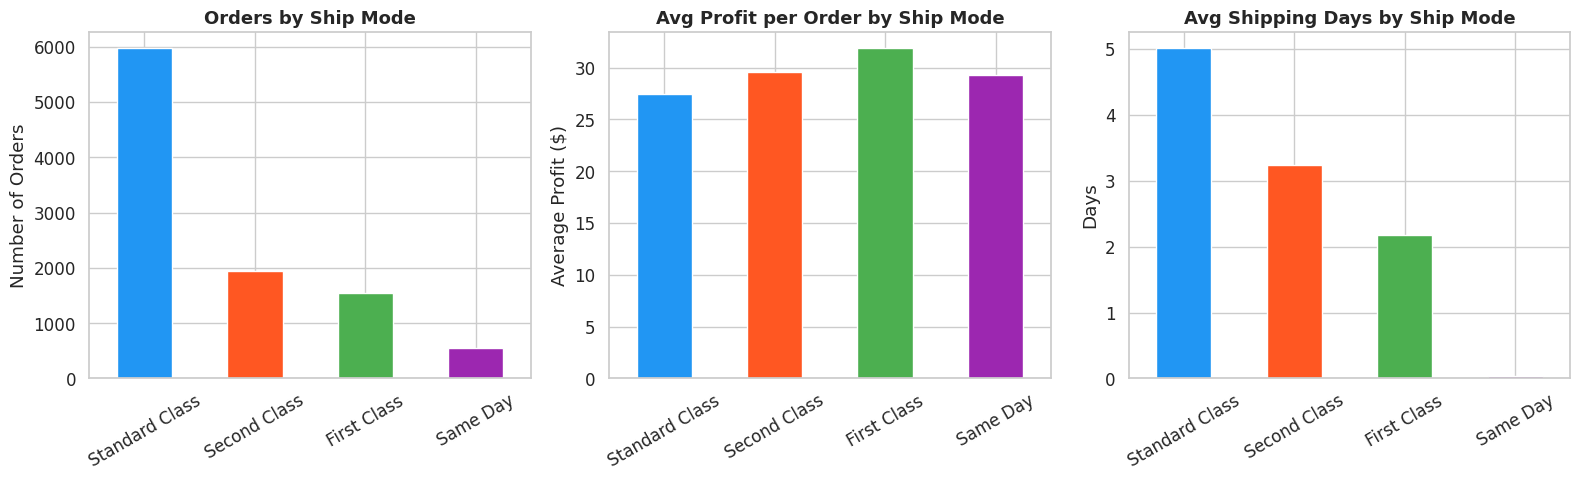

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Order distribution
ship_summary['Order_Count'].plot(kind='bar', ax=axes[0], color=PALETTE, edgecolor='white')
axes[0].set_title('Orders by Ship Mode', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Orders')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

# Average profit per order
ship_summary['Avg_Profit'].plot(kind='bar', ax=axes[1], color=PALETTE, edgecolor='white')
axes[1].set_title('Avg Profit per Order by Ship Mode', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Average Profit ($)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

# Average shipping days
ship_summary['Avg_Ship_Days'].plot(kind='bar', ax=axes[2], color=PALETTE, edgecolor='white')
axes[2].set_title('Avg Shipping Days by Ship Mode', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Days')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 📌 So What? — Shipping Modes
- **Standard Class handles ~60% of orders** and is the workhorse, but Same Day and First Class yield comparable or better per-order profit.
- **Same Day shipping shows slightly higher average profit** — customers choosing it likely have higher willingness-to-pay and buy premium products.
- **Recommendation:** Consider nudging high-value orders toward First Class/Same Day with minimal discounts, as these modes don't appear to hurt margins.

---
## 8. RFM Customer Analysis
RFM (Recency, Frequency, Monetary) analysis segments customers based on their purchasing behavior:
- **Recency:** How recently did the customer buy? (lower = better)
- **Frequency:** How often do they buy? (higher = better)
- **Monetary:** How much do they spend? (higher = better)

### Calculating RFM Scores

In [30]:
# Use the latest date in the dataset as our reference point
snapshot_date = df['Order Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg(
    Recency=('Order Date', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Order ID', 'nunique'),
    Monetary=('Sales', 'sum')
).round(2)

# Score each dimension 1-4 using quartiles (4 = best)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1])  # lower recency = higher score
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4])

# Combined RFM score
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

print(f'Total customers analyzed: {len(rfm)}')
rfm.head(10)

Total customers analyzed: 793


,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
Customer ID,,,,,,,
AA-10315,185,5,5563.56,1,1,4,114
AA-10375,20,9,1056.39,4,4,1,441
AA-10480,260,4,1790.51,1,1,2,112
AA-10645,56,6,5086.93,3,2,4,324
AB-10015,416,3,886.16,1,1,1,111
AB-10060,55,8,7755.62,3,3,4,334
AB-10105,42,10,14473.57,3,4,4,344
AB-10150,42,5,966.71,3,1,1,311
AB-10165,26,8,1113.84,4,3,1,431


### Segmenting Customers into Business Categories
We map RFM scores to human-readable segments so the business can take action.

In [31]:
def rfm_segment(row):
    r, f, m = int(row['R_Score']), int(row['F_Score']), int(row['M_Score'])
    if r >= 3 and f >= 3 and m >= 3:
        return 'Champions'
    elif r >= 3 and f >= 2 and m >= 2:
        return 'Loyal Customers'
    elif r >= 3 and f <= 2:
        return 'New Customers'
    elif r == 2 and f >= 2:
        return 'At Risk'
    elif r <= 1 and f >= 2:
        return 'Cant Lose Them'
    elif r <= 2 and f <= 2 and m >= 2:
        return 'Hibernating'
    else:
        return 'Lost'

rfm['Segment'] = rfm.apply(rfm_segment, axis=1)

# Summary of segments
segment_summary = rfm.groupby('Segment').agg(
    Count=('Recency', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).sort_values('Avg_Monetary', ascending=False).round(1)

segment_summary

,Count,Avg_Recency,Avg_Frequency,Avg_Monetary
Segment,,,,
Champions,176,33.2,8.8,4562.1
Cant Lose Them,104,332.6,6.5,3246.2
At Risk,165,117.1,7.2,3226.2
Loyal Customers,117,31.9,6.5,2657.9
Hibernating,54,384.0,3.5,2407.6
New Customers,93,36.9,3.8,1456.9
Lost,84,351.7,3.4,569.9


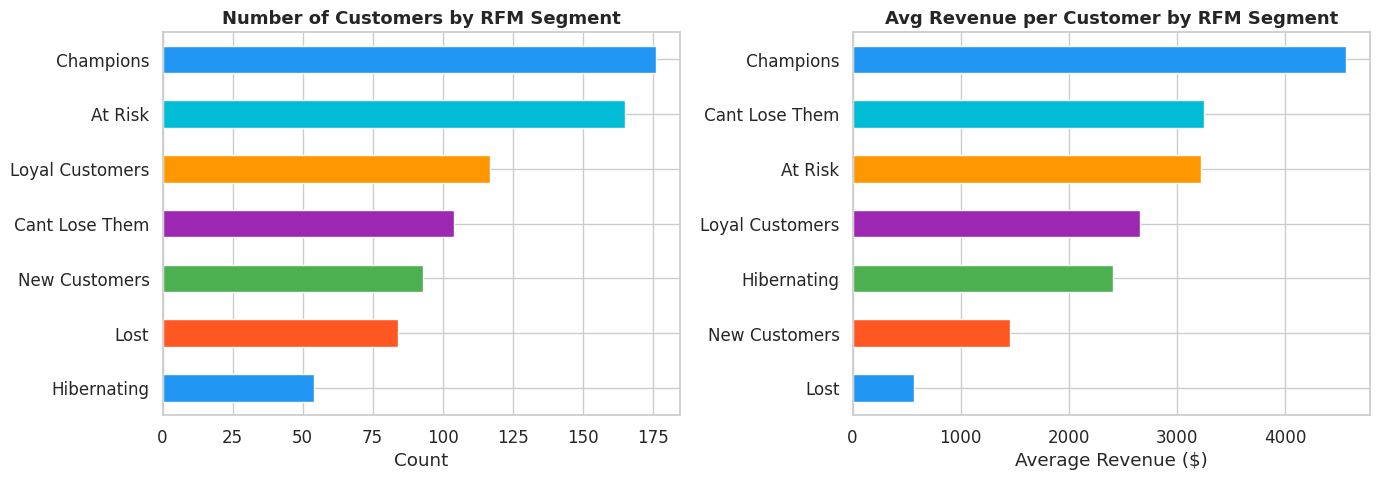

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Customer count by segment
seg_counts = segment_summary['Count'].sort_values(ascending=True)
seg_counts.plot(kind='barh', ax=axes[0], color=PALETTE[:len(seg_counts)], edgecolor='white')
axes[0].set_title('Number of Customers by RFM Segment', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('')

# Average monetary value by segment
seg_monetary = segment_summary['Avg_Monetary'].sort_values(ascending=True)
seg_monetary.plot(kind='barh', ax=axes[1], color=PALETTE[:len(seg_monetary)], edgecolor='white')
axes[1].set_title('Avg Revenue per Customer by RFM Segment', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average Revenue ($)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

### 📌 So What? — RFM Customer Analysis
- **Champions** (high R, F, M) are repeat, high-value buyers — protect them with loyalty perks, not discounts.
- **"Can't Lose Them"** customers used to buy frequently but haven't purchased recently — run a win-back campaign with personalized offers.
- **New Customers** have bought recently but infrequently — nurture them with onboarding emails and product recommendations.
- **Lost/Hibernating** customers may not be worth reactivation spend unless their past monetary value was high.

---
## 9. Sales Trends & Seasonality
### Monthly Sales by Year
A line chart showing monthly sales for each year helps us spot seasonal patterns.

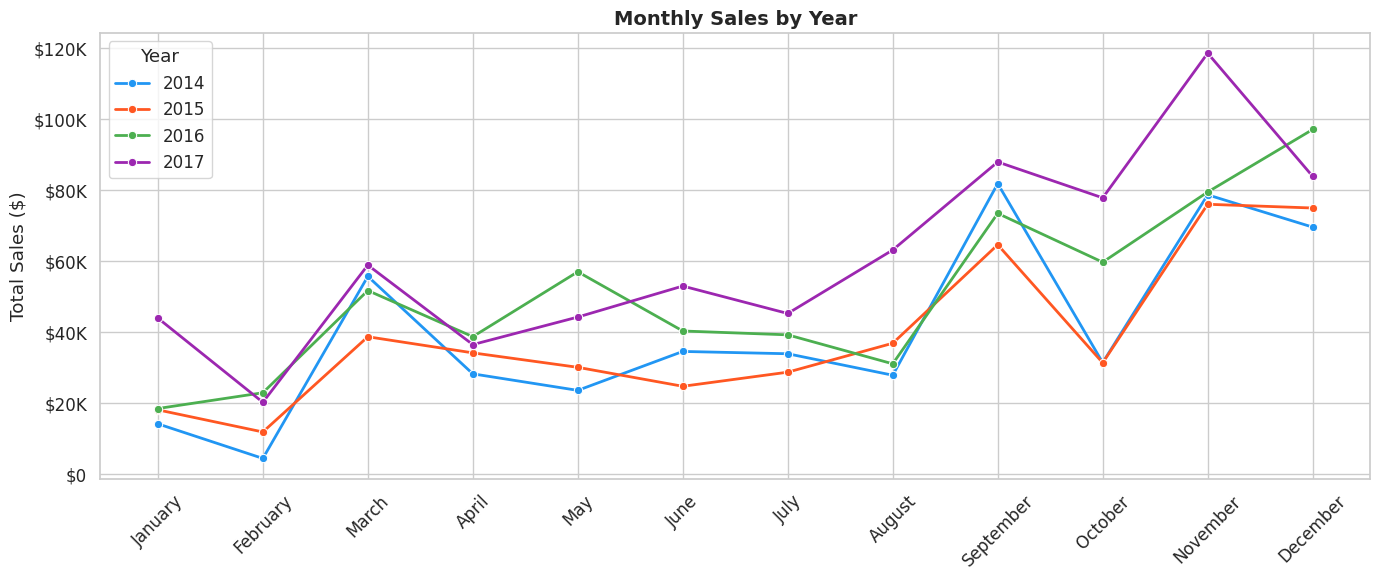

In [33]:
# Ensure proper month ordering
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

monthly_sales = df.groupby(['Year', 'Month Name'])['Sales'].sum().reset_index()
monthly_sales['Month Name'] = pd.Categorical(monthly_sales['Month Name'],
                                              categories=month_order, ordered=True)
monthly_sales = monthly_sales.sort_values(['Year', 'Month Name'])

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(data=monthly_sales, x='Month Name', y='Sales', hue='Year',
             marker='o', palette=PALETTE, linewidth=2, ax=ax)
ax.set_title('Monthly Sales by Year', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Total Sales ($)')
ax.yaxis.set_major_formatter(FuncFormatter(dollar_fmt))
plt.xticks(rotation=45)
ax.legend(title='Year')
plt.tight_layout()
plt.show()

### Yearly Sales by Region
How has each region grown year-over-year?

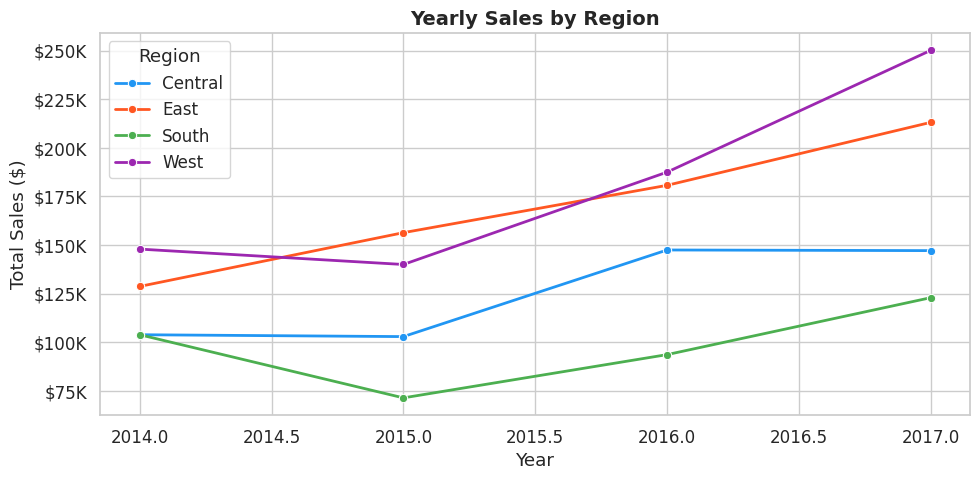

In [34]:
yearly_region = df.groupby(['Year', 'Region'])['Sales'].sum().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=yearly_region, x='Year', y='Sales', hue='Region',
             marker='o', palette=PALETTE, linewidth=2, ax=ax)
ax.set_title('Yearly Sales by Region', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Sales ($)')
ax.yaxis.set_major_formatter(FuncFormatter(dollar_fmt))
ax.legend(title='Region')
plt.tight_layout()
plt.show()

### Year-over-Year Growth Rate
Raw totals are useful, but growth *rates* tell us whether the business is accelerating or decelerating.

In [35]:
yearly_sales = df.groupby('Year')['Sales'].sum().reset_index()
yearly_sales['YoY_Growth_%'] = yearly_sales['Sales'].pct_change() * 100
yearly_sales = yearly_sales.round(2)
yearly_sales

,Year,Sales,YoY_Growth_%
0,2014,484247.50,NaN
1,2015,470532.51,-2.83
2,2016,609205.60,29.47
3,2017,733215.26,20.36


### Monthly Trend with Trendline
We aggregate all sales into a monthly time series and fit a simple linear trend to show the overall direction.

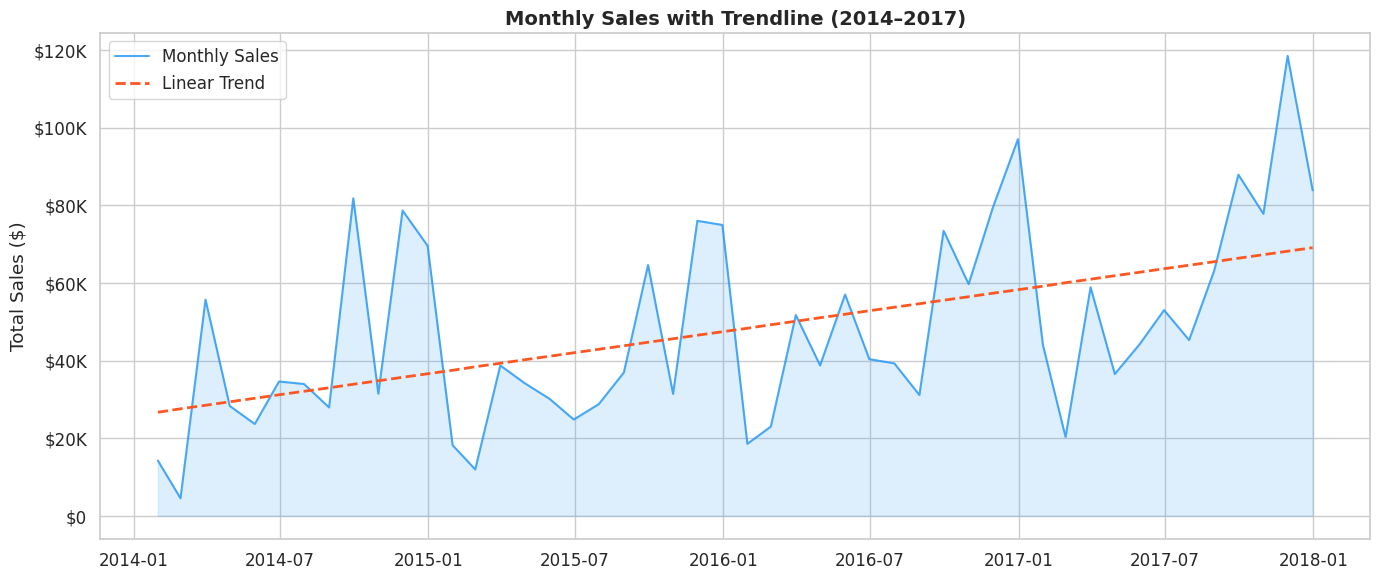

Average monthly sales growth (trend slope): $902/month


In [36]:
# Create a proper time series index
monthly_ts = df.set_index('Order Date').resample('M')['Sales'].sum().reset_index()
monthly_ts.columns = ['Date', 'Sales']

# Add a numeric index for trendline fitting
monthly_ts['Month_Num'] = range(len(monthly_ts))

# Fit a linear trend
z = np.polyfit(monthly_ts['Month_Num'], monthly_ts['Sales'], 1)
trendline = np.poly1d(z)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly_ts['Date'], monthly_ts['Sales'], color=PALETTE[0],
        linewidth=1.5, alpha=0.8, label='Monthly Sales')
ax.plot(monthly_ts['Date'], trendline(monthly_ts['Month_Num']),
        color=PALETTE[1], linewidth=2, linestyle='--', label='Linear Trend')
ax.fill_between(monthly_ts['Date'], monthly_ts['Sales'], alpha=0.15, color=PALETTE[0])
ax.set_title('Monthly Sales with Trendline (2014–2017)', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Total Sales ($)')
ax.yaxis.set_major_formatter(FuncFormatter(dollar_fmt))
ax.legend()
plt.tight_layout()
plt.show()

monthly_growth = z[0]  # slope per month
print(f'Average monthly sales growth (trend slope): ${monthly_growth:,.0f}/month')

### Month-over-Month Growth Rate
This view shows the volatility and seasonality of growth, not just the trend.

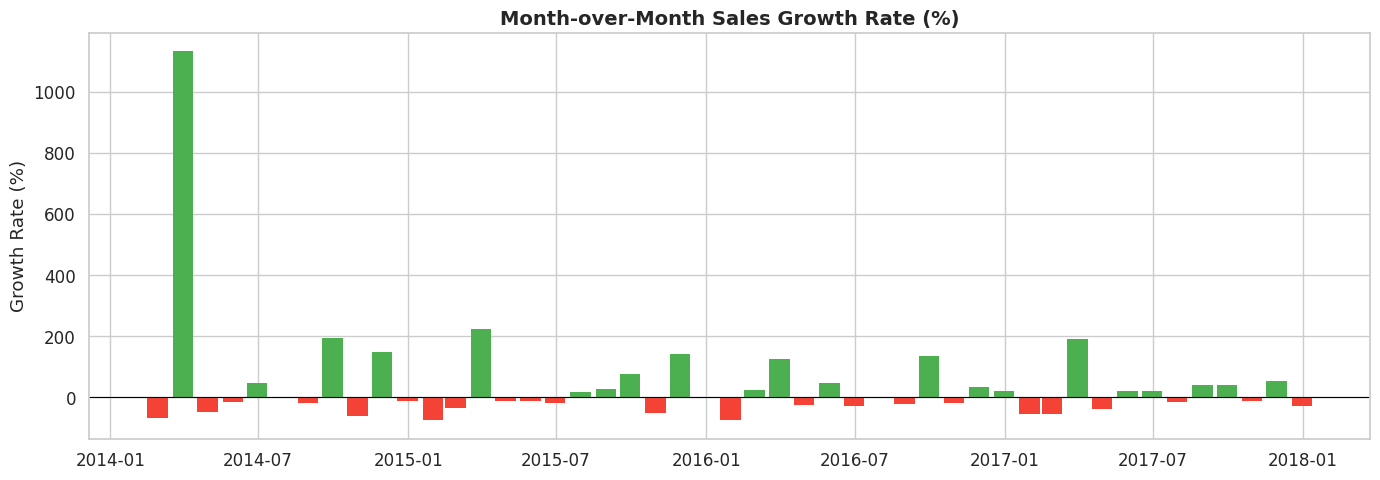

In [37]:
monthly_ts['MoM_Growth_%'] = monthly_ts['Sales'].pct_change() * 100

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#4CAF50' if v >= 0 else '#F44336' for v in monthly_ts['MoM_Growth_%'].fillna(0)]
ax.bar(monthly_ts['Date'], monthly_ts['MoM_Growth_%'], color=colors, width=25, edgecolor='none')
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_title('Month-over-Month Sales Growth Rate (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Growth Rate (%)')
plt.tight_layout()
plt.show()

### 📌 So What? — Sales Trends
- **Consistent year-over-year growth of ~20%** — the business is on a healthy upward trajectory.
- **Strong Q4 seasonality** — November and December consistently spike. The business should plan inventory and staffing accordingly.
- **February and January are the weakest months** — consider running targeted promotions during Q1 to smooth out the seasonal dip.
- **The linear trend suggests growth is steady, not accelerating** — to reach the next level, the business needs to either enter new markets or increase wallet share with existing customers.

---
## 10. Loss-Making Products
### Top 15 Products with the Highest Losses
These products are actively destroying value. The business should consider discontinuing them or renegotiating supplier terms.

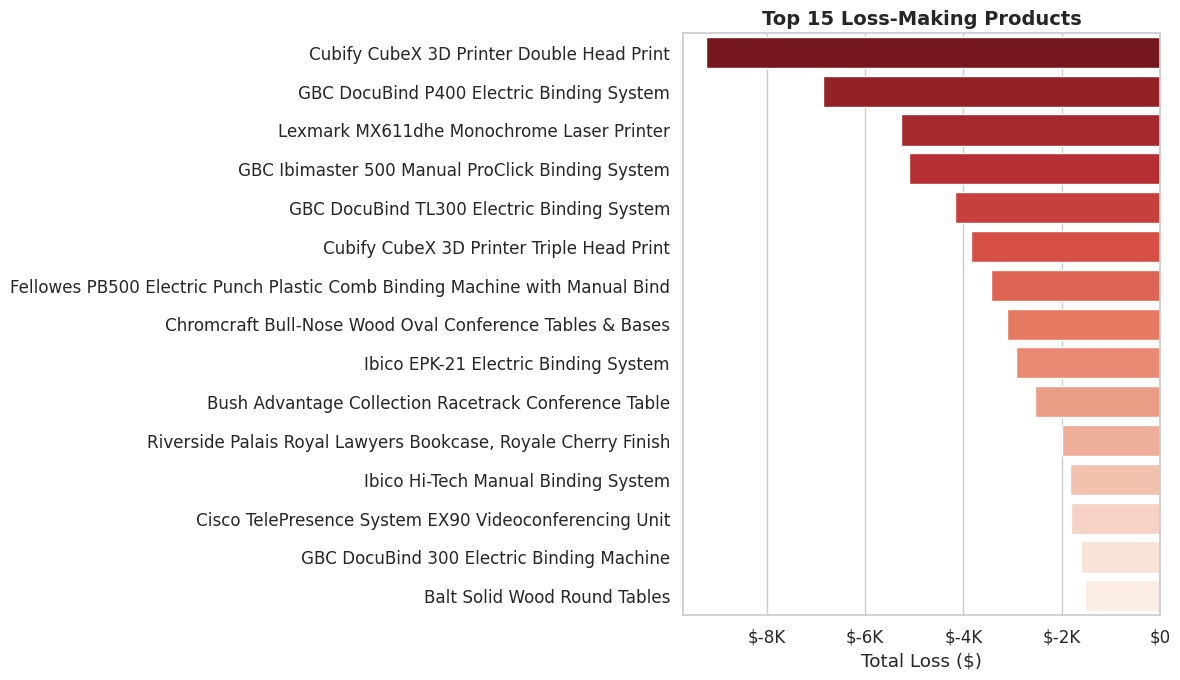


Note: Average discount % for these products:


,Total_Loss,Avg_Discount
Product Name,,
Cubify CubeX 3D Printer Double Head Print,-9239.97,70.00
GBC DocuBind P400 Electric Binding System,-6859.39,76.67
Lexmark MX611dhe Monochrome Laser Printer,-5269.97,50.00
GBC Ibimaster 500 Manual ProClick Binding System,-5098.57,71.67
GBC DocuBind TL300 Electric Binding System,-4162.03,72.50
Cubify CubeX 3D Printer Triple Head Print,-3839.99,50.00
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,-3431.67,80.00
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,-3107.53,35.00
Ibico EPK-21 Electric Binding System,-2929.48,80.00


In [38]:
loss_products = df[df['Profit'] < 0].groupby('Product Name').agg(
    Total_Loss=('Profit', 'sum'),
    Times_Sold=('Profit', 'count'),
    Avg_Discount=('Discount %', 'mean')
).sort_values('Total_Loss').head(15).round(2)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(data=loss_products.reset_index(), y='Product Name', x='Total_Loss',
            palette='Reds_r', edgecolor='white', ax=ax)
ax.set_title('Top 15 Loss-Making Products', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Loss ($)')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(FuncFormatter(dollar_fmt))
plt.tight_layout()
plt.show()

print('\nNote: Average discount % for these products:')
loss_products[['Total_Loss', 'Avg_Discount']]

### 📌 So What? — Loss-Making Products
- Most of the biggest loss-makers are **Furniture items (Tables, Bookcases)** sold at steep discounts — reinforcing our earlier discount analysis.
- Some of these products have been sold dozens of times at a loss — this isn't a one-off issue, it's a *systemic pricing problem*.
- **Recommendation:** Flag the top 15 loss-making products for SKU review. Either renegotiate supplier pricing, increase selling price, or discontinue.

---
## 11. Conclusion & Recommendations

After analyzing 9,994 transactions across four years, here are the **top 5 concrete business actions** this data supports:

### 1. Cap Discounts on Furniture at 20%
Discounts above 20% are profit-negative on average. Tables and Bookcases lose money at almost *any* discount level. Implement a hard cap and require VP approval for exceptions.

### 2. Invest in Technology Category Growth
Technology delivers the highest profit margins (especially Copiers and Accessories). Allocate more marketing budget here — even discounted Technology products remain profitable.

### 3. Fix the Central Region
Central generates the 2nd most sales but the lowest profit margin. Audit the discount practices of Central region sales reps, particularly on Consumer–Furniture orders.

### 4. Run a Win-Back Campaign for "Can't Lose Them" Customers
RFM analysis identified a segment of previously high-value customers who haven't purchased recently. A targeted reactivation campaign (personalized offers, not blanket discounts) could recover significant revenue.

### 5. Prepare for Q4 and Smooth Q1
November–December account for a disproportionate share of annual sales. Ensure inventory and support staffing scale for Q4 demand. Simultaneously, run Q1 promotions on high-margin categories (Technology, Office Supplies) to reduce the seasonal dip.

---
*Thank you for reading this analysis! If you found it useful, I'd appreciate an upvote on Kaggle.* 🙏

---
## 12. Save Processed Data
Finally, we save the enriched dataset with all our new columns for further use or sharing.

In [39]:
df.to_csv('processed_sales_data.csv', index=False)
print(f'Processed data saved: {df.shape[0]:,} rows × {df.shape[1]} columns')
print('New columns added:', [c for c in df.columns if c not in data.columns])

Processed data saved: 9,994 rows × 28 columns
New columns added: ['Month', 'Month Name', 'Year', 'Ship Days', 'Discount %', 'Profit Margin %', 'Discount Bucket']
